# Latent Variable Models (Logistic Regression)

### Foundations of Machine Learning

**Q1.** Please answer the following questions in your own words:

1. Why do we use general linear models/latent variable models/activation functions in analysis? What advantage do they have over linear models?

We use latent variable models because they allow us to limit our y to some desired range. In linear models, outcomes can be anywhere from -infinity to positive infinity. Latent variable models allow us to limit this to probabilities between 0 & 1 (logit), counts (Poisson), categories (multinomial logit), etc.

2. Explain why binary and categorical cross entropy are effective loss functions for fitting logistic regression models.

We can see from the mathematical properties of BCE(b)= $−[y_i​log(p_i(b)​)+(1−y_i​)log(1−p_i(b)​)]$, which we want to minimize, that it gives a small penalty when the model assigns a high probability to the correct class and a large penalty when it is confidently wrong. For example, if $y_i =1 $ and the model predicts $p_i = 0.99$, the loss is tiny. If $y_i =1 $ and the model predicts $p_i = 0.01$, the loss is huge.

Categorical cross entropy operates on the same principles: it just adds in a summation to the kth power if you have k categories of $y_{ik}log(p_{ik})$, and we also want to minimze this. This also means that loss is small when the model puts high probability on the true class, and large when it puts low probability on the true class.

Because cross entropy rewards high probabilities on the true class, it is a good loss function.

3. True or false, and explain: Logistic regression is a linear model.

False: logistic regression has the latent linear variable $L_{ik} = \beta_k \cdot x_i + \epsilon_{ik}$, but this is then fed into the logistic distribution $F(L) = \frac{e^L}{1+e^L}$, which is non-linear. To borrow from the slides, 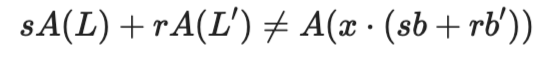

(note: I know LaTeX I promise I'm not using AI)

4. True or false, and explain: Logistic regression cannot be used for classification.

False: you can classify with logistic regression by just assigning above a certain probability threshold to 1, and below to 0:

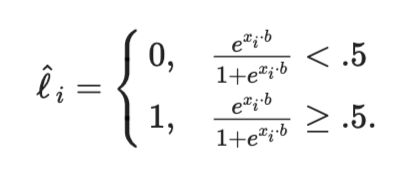

5. Does the coefficient in a logistic regression represent the change in the predicted value for a 1 unit change in the feature/covariate/explanatory variable?

No, logistic regression is not linear. We can broadly interpret the coefficient as positive = more likely and negative = less likely, but it's hard to reach a deeper interpretation.

6. True or false, and explain: Feature engineering is unnecessary for logistic regression, because it is a nonlinear model.

False: we still need to do interactions, powers, one-hot encoding, transformation to get logit to work properly -- we can't just "dump data into the woodchipper" because otherwise, we'll end up without the proper relationships between our features.

7. True or false, and explain: Logistic regression is an improvement over the usual linear model (ordinary least squares), and you should always use logistic regression instead.

False: logit is good at providing probabilities between 0 & 1, and bad when you need any other use case (negative ys, going beyond 0 and 1, etc.).

**Q2.** This is a question about student dropout probability.

The relevant data are in `data.csv` and the file is semicolon-separated.

The relevant variables are:
- `Debtor` - `1` if the student has outstanding debt and `0` otherwise
- `Tuition fees up to date` - `1` if tuition is up to date and `0` otherwise
- `Scholarship holder` - `1` if the student has a scholarship and `0` otherwise
- `Age at enrollment` - student's age when entering the program
- `Curricular units 1st sem (approved)` - number of first-semester courses passed
- `Target` - `Dropout`, `Graduate`, or `Enrolled`

1. Load the data, `data.csv`. Be sure to read it with the correct delimiter. Filter on columns to the variables we'll actually use. Document how you handle any missing values. For parts 2-5, create a binary target where `Dropout` corresponds to dropout and `Graduate` or `Enrolled` corresponds to not dropout.


In [ ]:
# Get data: manually download https://github.com/ds4e/undergrad_ml_assignments/blob/main/data/data.csv

# Import libraries
from sklearn.linear_model import LassoCV, lasso_path, LinearRegression, Lasso, LogisticRegression
from sklearn.metrics import mean_squared_error
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
from sklearn.model_selection import KFold, cross_val_score, train_test_split
from sklearn.preprocessing import PolynomialFeatures, StandardScaler

In [ ]:
# Load data
df = pd.read_csv('/content/data.csv', sep=";").rename(columns=lambda c: c.strip())
df.dtypes

,0
Marital status,int64
Application mode,int64
Application order,int64
Course,int64
Daytime/evening attendance,int64
Previous qualification,int64
Previous qualification (grade),float64
Nacionality,int64
Mother's qualification,int64
Father's qualification,int64


In [ ]:
# Make individual dummies

# Clean Target values
df["Target"] = df["Target"].astype(str).str.strip()

# Create outcome dummies
df["Dropout"] = (df["Target"] == "Dropout").astype(int)
df["Graduate"] = (df["Target"] == "Graduate").astype(int)
df["Enrolled"] = (df["Target"] == "Enrolled").astype(int)

# Check
df[["Target", "Dropout", "Graduate", "Enrolled"]].head()

,Target,Dropout,Graduate,Enrolled
0,Dropout,1,0,0
1,Graduate,0,1,0
2,Dropout,1,0,0
3,Graduate,0,1,0
4,Graduate,0,1,0


In [ ]:
df = df[
    [
        "Debtor",
        "Tuition fees up to date",
        "Scholarship holder",
        "Age at enrollment",
        "Curricular units 1st sem (approved)",
        "Dropout",
        "Graduate",
        "Enrolled",
        "Target"
    ]
]
df.head()

,Debtor,Tuition fees up to date,Scholarship holder,Age at enrollment,Curricular units 1st sem (approved),Dropout,Graduate,Enrolled,Target
0,0,1,0,20,0,1,0,0,Dropout
1,0,0,0,19,6,0,1,0,Graduate
2,0,0,0,19,0,1,0,0,Dropout
3,0,1,0,20,6,0,1,0,Graduate
4,0,1,0,45,5,0,1,0,Graduate


2. Run a logistic regression of dropout status on `Debtor`, `Tuition fees up to date`, `Scholarship holder`, and `Age at enrollment`. Which variables predict a higher dropout probability, and which predict a lower dropout probability? Does being up to date on tuition seem to reduce dropout risk?


In [ ]:
y = df['Dropout']
X = df[['Debtor', 'Tuition fees up to date', 'Scholarship holder', 'Age at enrollment']]
reg = LogisticRegression(penalty=None)
reg = reg.fit(X,y)
pd.DataFrame({'Variable':reg.feature_names_in_,'Coefficient':reg.coef_[0]})

,Variable,Coefficient
0,Debtor,0.527137
1,Tuition fees up to date,-2.605617
2,Scholarship holder,-1.242299
3,Age at enrollment,0.049841


Debtor and less strongly age seem to predict a higher drop out probability, while being up to date with tuition + scholarship reduce probability.

3. Use `.predict_proba` and compute expected dropout probabilities. Make a scatter plot of your predicted dropout probability against `Age at enrollment`, hued by `Tuition fees up to date`. For what ages does being up to date on tuition seem to reduce dropout probability the most? On average, by how much does being up to date on tuition change the predicted probability of dropout?

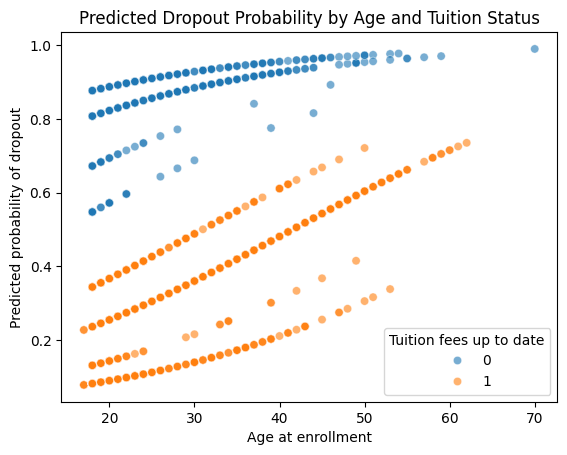

In [ ]:
# Predicted probability of dropout = 1
y_reg = reg.predict_proba(X)[:, 1]

sns.scatterplot(
    x=df["Age at enrollment"],
    y=y_reg,
    hue=df["Tuition fees up to date"],
    alpha=0.6
)

plt.title("Predicted Dropout Probability by Age and Tuition Status")
plt.xlabel("Age at enrollment")
plt.ylabel("Predicted probability of dropout")
plt.show()

Being up to date on tuition seems to reduce dropout rates the most at ages before 20 (the youngest part of the graph). On average, being up to date on tuition increases dropout probability by about 0.3 points.


4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

In [ ]:
y_class = pd.Series( reg.predict(X) )

tab = pd.crosstab( y_class, df['Dropout'])
acc = np.trace(tab)/len(y_class)
print(f'Confusion matrix:\n {tab}')
print(f'\nAccuracy: {acc}')

Confusion matrix:
 Dropout     0    1
row_0             
0        2841  891
1         162  530

Accuracy: 0.7619801084990958


5. Compute predicted dropout probabilities with a linear model with the same variables, and predict dropout probabilities. Make a histogram of predicted probabilities for both logistic regression and the linear model. Compare their performance.

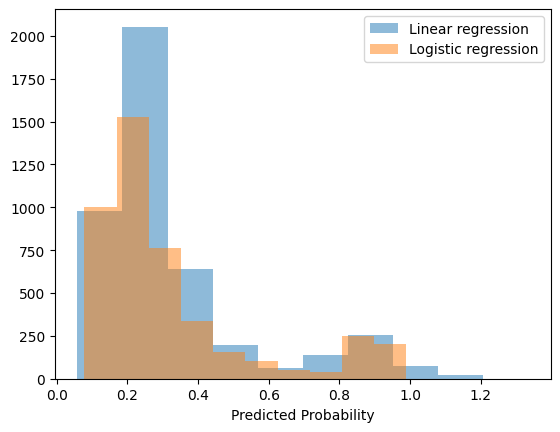

In [ ]:
# Linear reg
y_hat = LinearRegression().fit(X,y).predict(X)

plt.hist(x=y_hat, alpha = 0.5, label='Linear regression')
plt.hist(x=y_reg, alpha = 0.5, label='Logistic regression')
plt.xlabel('Predicted Probability')
plt.legend()
plt.show()

Linear regression is spikier, with much more values in that 0.2-0.3 bin and less granularity overall. Log regression is much more granular. Linear regression also predicts some probabilities above 1.0, which is impossible.

6. Based on your above work, which students are the most at-risk of dropping out? What kinds of interventions can you imagine that would help at-risk students stay enrolled?


Young students who are non-scholarship holders and not up to date with tuition payments are most at risk of dropping out. Tuition amnesty, granting of loans at reduced rates or scholarships, or other financial assistance would help them stay enrolled.

7. Run a multinomial logistic regression of `Target` on `Debtor`, `Tuition fees up to date`, and `Curricular units 1st sem (approved)`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [ ]:
X = df[['Debtor', 'Tuition fees up to date', 'Curricular units 1st sem (approved)']]
y = df['Target']

mnl = LogisticRegression(penalty=None).fit(X,y)
mnl_coef = pd.DataFrame(mnl.coef_)
mnl_coef = mnl_coef.set_axis(mnl.feature_names_in_,axis=1)
mnl_coef

,Debtor,Tuition fees up to date,Curricular units 1st sem (approved)
0,0.364253,-1.782824,-0.289422
1,0.279227,0.207343,-0.025537
2,-0.643480,1.575481,0.314959


In [ ]:
classes = sorted(pd.Series(y).unique())

pd.crosstab(
    pd.Categorical(y, categories=classes),
    pd.Categorical(mnl.predict(X), categories=classes),
    rownames=["Actual"],
    colnames=["Predicted"],
    dropna=False
)

Predicted,Dropout,Enrolled,Graduate
Actual,,,
Dropout,1054,0,367
Enrolled,280,0,514
Graduate,146,0,2063


The hard classification is OK at predicting dropouts and graduates. However, it never predicts enrolled, which is a glaring issue.

In [ ]:
pd.DataFrame(mnl.predict_proba(X))

,0,1,2
0,0.680560,0.210486,0.108954
1,0.706615,0.145494,0.147892
2,0.954343,0.040341,0.005316
3,0.117346,0.176786,0.705867
4,0.183691,0.212551,0.603758
...,...,...,...
4419,0.183691,0.212551,0.603758
4420,0.790188,0.149440,0.060372
4421,0.071581,0.140405,0.788013
4422,0.183691,0.212551,0.603758


My predicted probabilities do predict for every class.

**Q3.** This is a question about 10-year survival rate for cirrhosis of the liver.

The relevant data are:
- `Bilirubin` - A liver byproduct produced when red blood cells break down
- `Edema` - Swelling in limbs; `N` for none, `S` for edema resolvable with diuretics, `Y` for edema despite dirutics
- `Drug` - D-penicillamine, or placebo
- `Stage` - current state of disease, from 1 to 4
- `Status` - `C` or `CL` corresponds to alive, and `D` corresponds to dead

1. Load the data, `cirrhosis.csv`. Filter on columns to the variables we'll actually use. Document how you handle any missing values.

In [ ]:
# Load data
df = pd.read_csv('/content/cirrhosis.csv').rename(columns=lambda c: c.strip())
df.dtypes

,0
ID,int64
N_Days,int64
Status,object
Drug,object
Age,int64
Sex,object
Ascites,object
Hepatomegaly,object
Spiders,object
Edema,object


In [ ]:
df = df[
    [
        "Bilirubin",
        "Edema",
        "Drug",
        "Stage",
        "Status"
    ]
]

df.head()

,Bilirubin,Edema,Drug,Stage,Status
0,14.5,Y,D-penicillamine,4.0,D
1,1.1,N,D-penicillamine,3.0,C
2,1.4,S,D-penicillamine,4.0,D
3,1.8,S,D-penicillamine,4.0,D
4,3.4,N,Placebo,3.0,CL


In [ ]:
df.isna().sum()

,0
Bilirubin,0
Edema,0
Drug,106
Stage,6
Status,0


In [ ]:
# It seems like we have 106 null obs for drugs, so we'll
# drop those observations as this is just a dummy and we can't
# take averages.

df = df.dropna(subset=["Drug"])

# For stage we will impute medians.

df["Stage"] = df["Stage"].fillna(df["Stage"].median())

df[["Bilirubin", "Edema", "Drug", "Stage", "Status"]].isna().sum()

,0
Bilirubin,0
Edema,0
Drug,0
Stage,0
Status,0


2. Run a logistic regression of `Status` on `Edema`, `Drug`, and `Bilirubin`. Does the drug improve survival probability? Does higher or lower bilirubin predict a higher or lower survival rate? How does survival rate vary with edema?

In [ ]:
# Generate binary outcome alive = 1, dead = 0
df["Alive"] = df["Status"].isin(["C", "CL"]).astype(int)

# Keep model vars and drop missing
model_df = df[["Alive", "Edema", "Drug", "Bilirubin"]].dropna().copy()

# Convert categorical Y/N variables into dummy variables
X = pd.get_dummies(
    model_df[["Edema", "Drug", "Bilirubin"]],
    columns=["Edema", "Drug"],
    drop_first=True,
    dtype=int
)

y = model_df["Alive"]

reg = LogisticRegression(penalty=None, max_iter=1000)
reg = reg.fit(X, y)

pd.DataFrame({
    "Variable": reg.feature_names_in_,
    "Coefficient": reg.coef_[0]
})

,Variable,Coefficient
0,Bilirubin,-0.350381
1,Edema_S,-0.578551
2,Edema_Y,-2.859322
3,Drug_Placebo,0.252657


3. Use `.predict_proba` and compute expected surivival probabilities. Make a scatter plot of your predicted survival probability against `Bilirubin`, hued by `Drug`. For what values of `Bilirubin` does the drug seem to increase patient survival rate? On average, by how much do patients who take the drug increase their probability of survival?


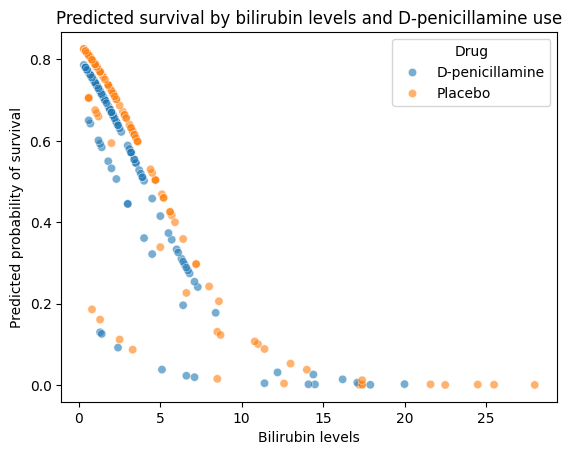

In [ ]:
# Predicted probability of survival = 1
y_reg = reg.predict_proba(X)[:, 1]

sns.scatterplot(
    x=df["Bilirubin"],
    y=y_reg,
    hue=df["Drug"],
    alpha=0.6
)

plt.title("Predicted survival by bilirubin levels and D-penicillamine use")
plt.xlabel("Bilirubin levels")
plt.ylabel("Predicted probability of survival")
plt.show()

D-penicillamine does not appear to significantly increase suvival rates -- if anything, taking the drug is associated with a slight decrease in survival.

4. Use `.predict` and compute a confusion matrix for your classifier. What is the accuracy?

In [ ]:
y_class = pd.Series( reg.predict(X) )

tab = pd.crosstab( y_class, df['Alive'])
acc = np.trace(tab)/len(y_class)
print(f'Confusion matrix:\n {tab}')
print(f'\nAccuracy: {acc}')

Confusion matrix:
 Alive   0    1
row_0         
0      57   14
1      68  173

Accuracy: 0.7371794871794872


5. Compute predicted survival probabilities with a linear model with the same variables, and predict survival probabilties. Make a histogram of predictive probabilties for both logistic regression and the linear model. Compare their performance.

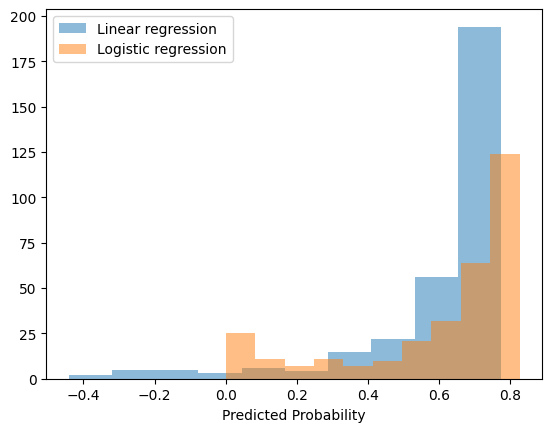

In [ ]:
# Linear reg
y_hat = LinearRegression().fit(X,y).predict(X)

plt.hist(x=y_hat, alpha = 0.5, label='Linear regression')
plt.hist(x=y_reg, alpha = 0.5, label='Logistic regression')
plt.xlabel('Predicted Probability')
plt.legend()
plt.show()

A logistic regression here is much more granular than the linear one. It also never predicts probabilities below 0 (impossible), while a linear regression does.

6. Run a logistic regression of `Stage` on `Edema` and `Bilirubin`. Use `.predict` to make a hard classification, and compute a confusion matrix. Describe your results. Use `.predict_proba` to predict probabilities instead and look at the values. Does your hard classification predict every class? Do your predicted probabilities predict every class?

In [ ]:
X = pd.get_dummies(
    df[["Edema", "Bilirubin"]],
    columns=["Edema"],
    drop_first=True,
    dtype=int
)

y = df["Stage"]

mnl = LogisticRegression(penalty=None, max_iter=1000).fit(X, y)

mnl_coef = pd.DataFrame(
    mnl.coef_,
    columns=mnl.feature_names_in_,
    index=mnl.classes_)

mnl_coef

,Bilirubin,Edema_S,Edema_Y
1.0,-0.442466,-9.386223,-4.528588
2.0,0.083878,2.756709,0.759773
3.0,0.156874,3.115830,1.034692
4.0,0.201714,3.513684,2.734123


In [ ]:
classes = sorted(pd.Series(y).unique())

pd.crosstab(
    pd.Categorical(y, categories=classes),
    pd.Categorical(mnl.predict(X), categories=classes),
    rownames=["Actual"],
    colnames=["Predicted"],
    dropna=False
)

Predicted,1.0,2.0,3.0,4.0
Actual,,,,
1.0,0,0,16,0
2.0,0,0,61,6
3.0,0,0,102,18
4.0,0,0,74,35


My hard classification does not predict any class 1 or 2, when 16 & 68 exist in reality. This is a pretty poorly-performing classification.

In [ ]:
pd.DataFrame(mnl.predict_proba(X))

,0,1,2,3
0,2.965432e-08,0.022548,0.124085,0.853367
1,7.611339e-02,0.252747,0.397286,0.273854
2,2.405392e-07,0.175629,0.404098,0.420273
3,1.887830e-07,0.170141,0.403070,0.426790
4,2.053819e-02,0.228845,0.425472,0.325145
...,...,...,...,...
307,1.108591e-01,0.254674,0.380373,0.254094
308,1.108591e-01,0.254674,0.380373,0.254094
309,5.456138e-02,0.248464,0.408039,0.288936
310,4.606378e-02,0.245648,0.412347,0.295941


My predicted probabilities are non-zero but very small for class 1, meaning that they basically do not predict class 1. Probabilities for class 2 are substantial and non-zero, but seem to never be larger than class 3 or 4 probabilities.

**Q4.** What are the coefficients of a logistic regression? How do you interpret their values?

1. For your linear model, your predictions are:
$$
\hat{y} = b \cdot x = b_0 + \sum_{k=1}^K b_k x_{k}
$$
What is the derivative of the prediction with respect to the $k$-th feature? For a 1 unit change in your feature, by how much does the prediction change?

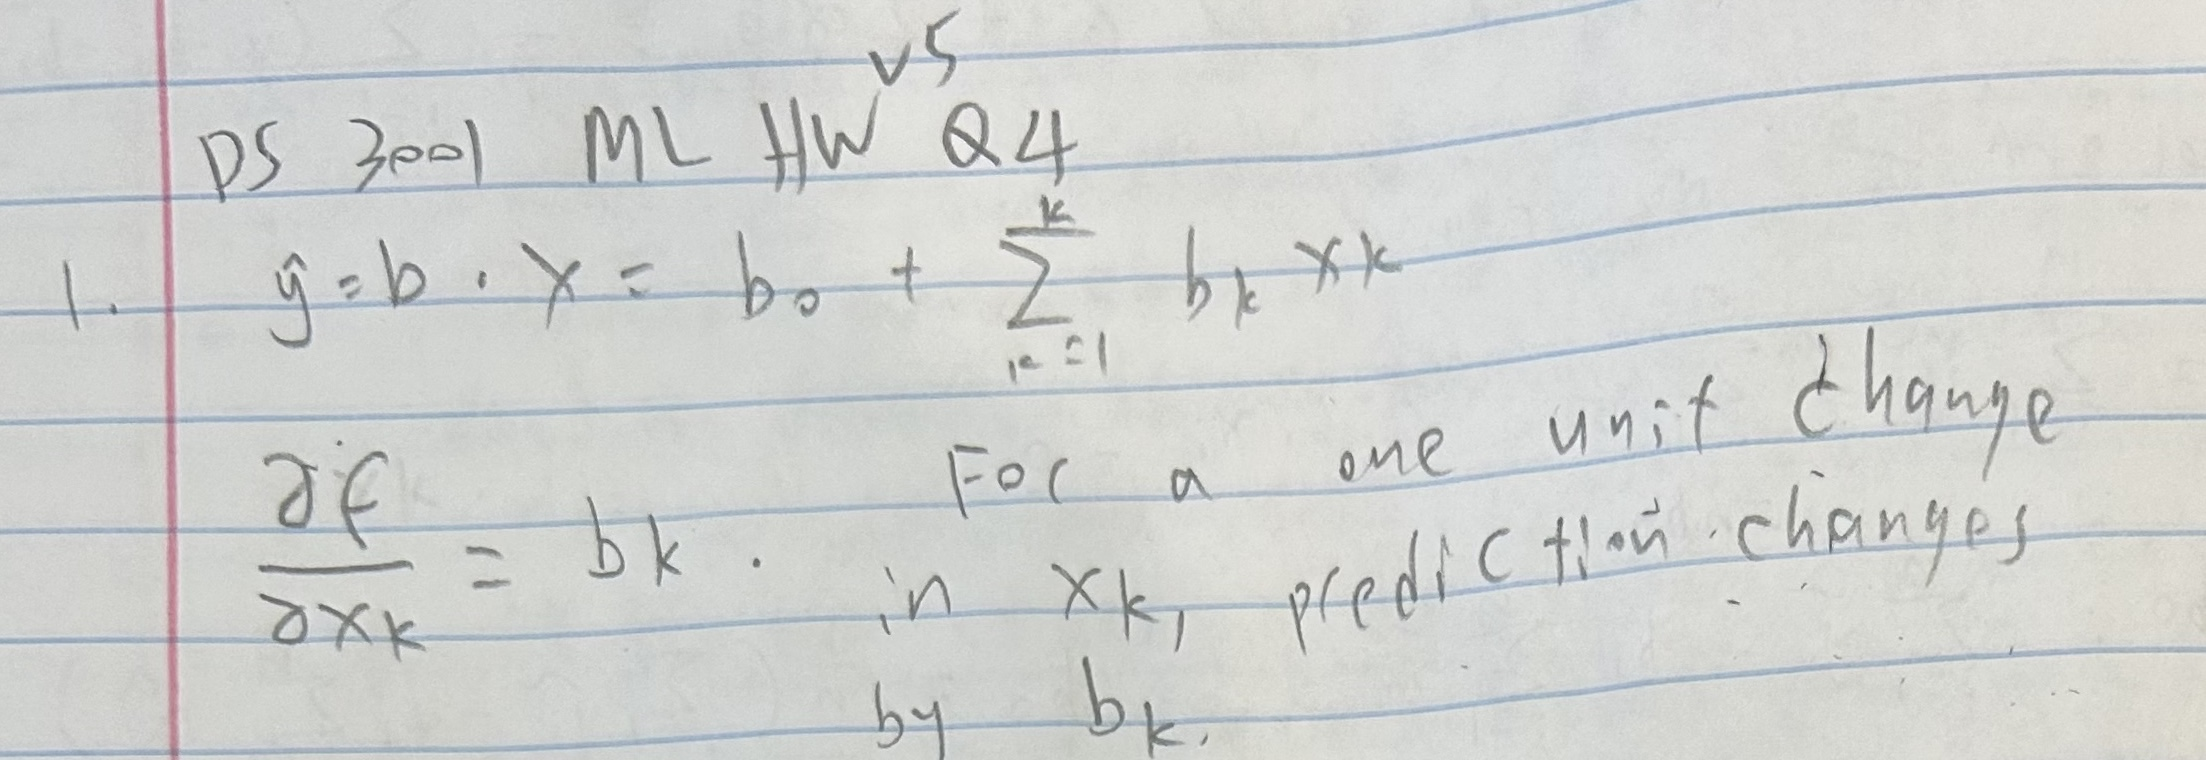

2. For the logistic model, your predictions are:
$$
\hat{p}_i = \dfrac{e^{b \cdot x}}{1+e^{b \cdot x}}
$$
What is the derivative of the prediction with respect to the $k$-th feature? As $x$ changes, does your answer change? How is it similar or different from your answer for part 1? Hint: It turns out that
$$
\frac{ \partial }{ \partial L} \dfrac{e^{L}}{1+e^{L}}= \frac{e^{L}}{(1+e^{L})^2} = \frac{e^{L}}{1+e^{L}}\frac{1}{1+e^{L}} = \frac{e^{L}}{1+e^{L}} \left( 1 - \frac{e^{L}}{1+e^{L}} \right),
$$
and use the chain rule( $D_x f(g(x)) = f'(g(x))g'(x)$). For what values of $\hat{p}$ is the coefficient itself (...times 4) roughly a good estimate of how a change in $x_k$ affects the prediction?

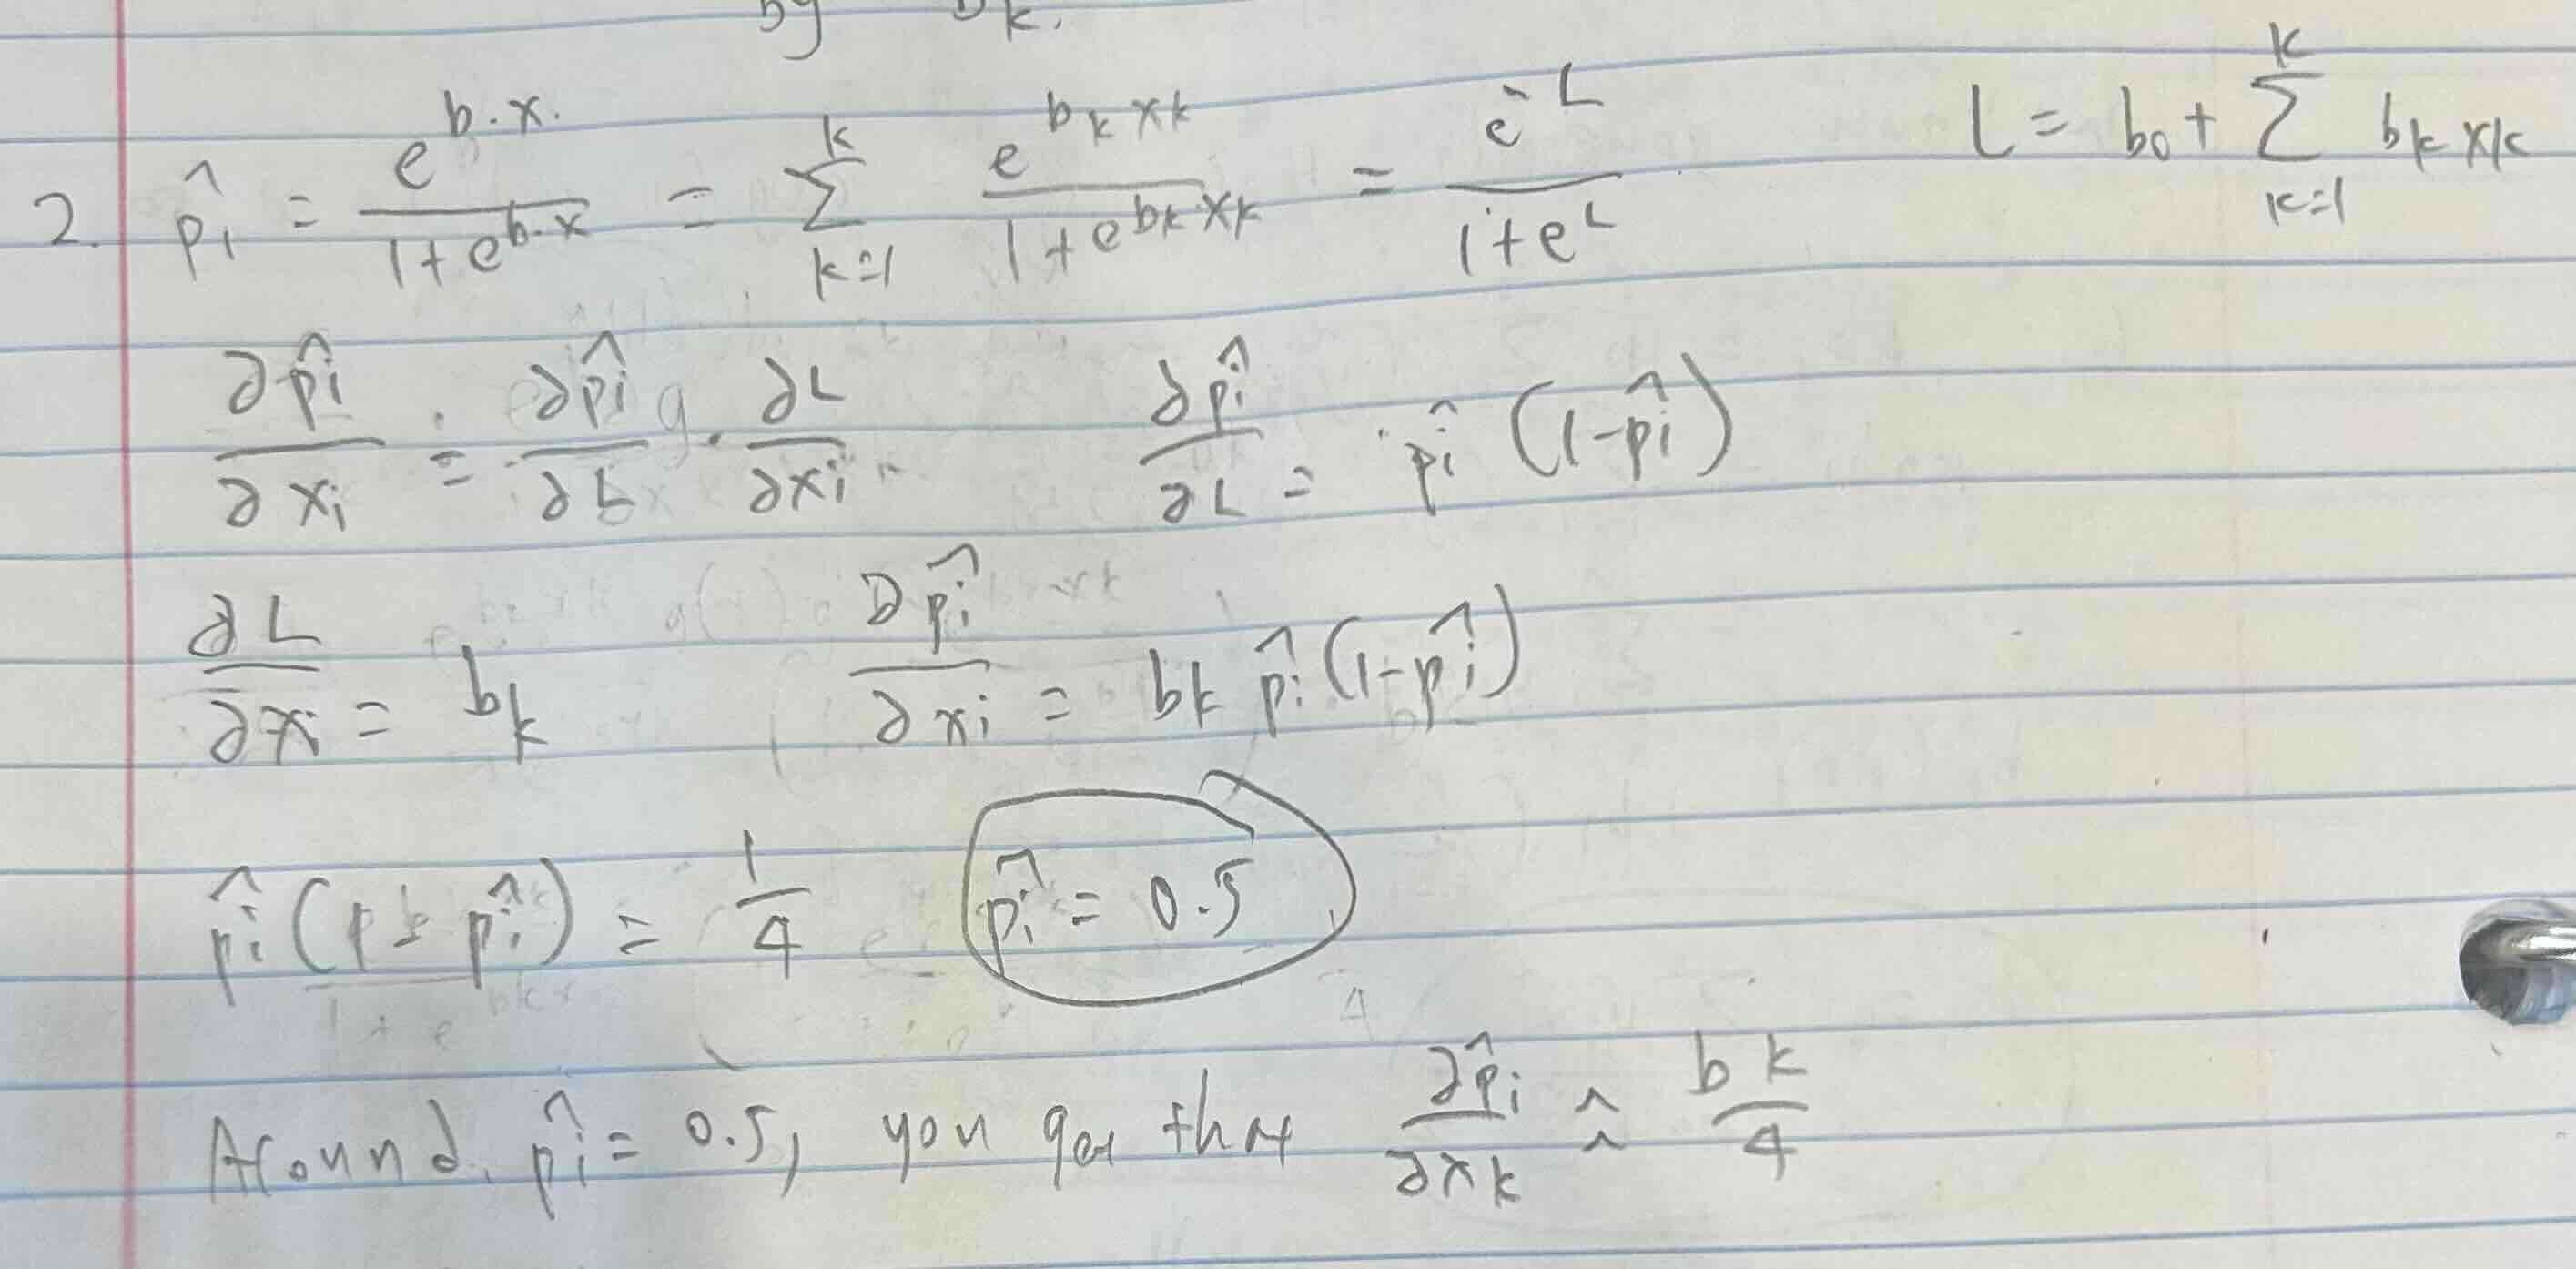

3. Alternatively, we can transform the prediction like this:

\begin{alignat*}{2}
\hat{p} &=& \frac{ e^{b \cdot x} }{1+e^{b \cdot x}} \\
\hat{p}(1+e^{b \cdot x}) &=& e^{b \cdot x} \\
\hat{p} &=& (1-\hat{p}) e^{b \cdot x} \\
\log \left( \frac{\hat{p}}{1-\hat{p}} \right) &=& b \cdot x \\
\end{alignat*}

The left-hand side of the above expression is called the **log odds ratio**, and the right-hand side is the latent variable. How does a one unit change in $x_k$ affect the log odds ratio?

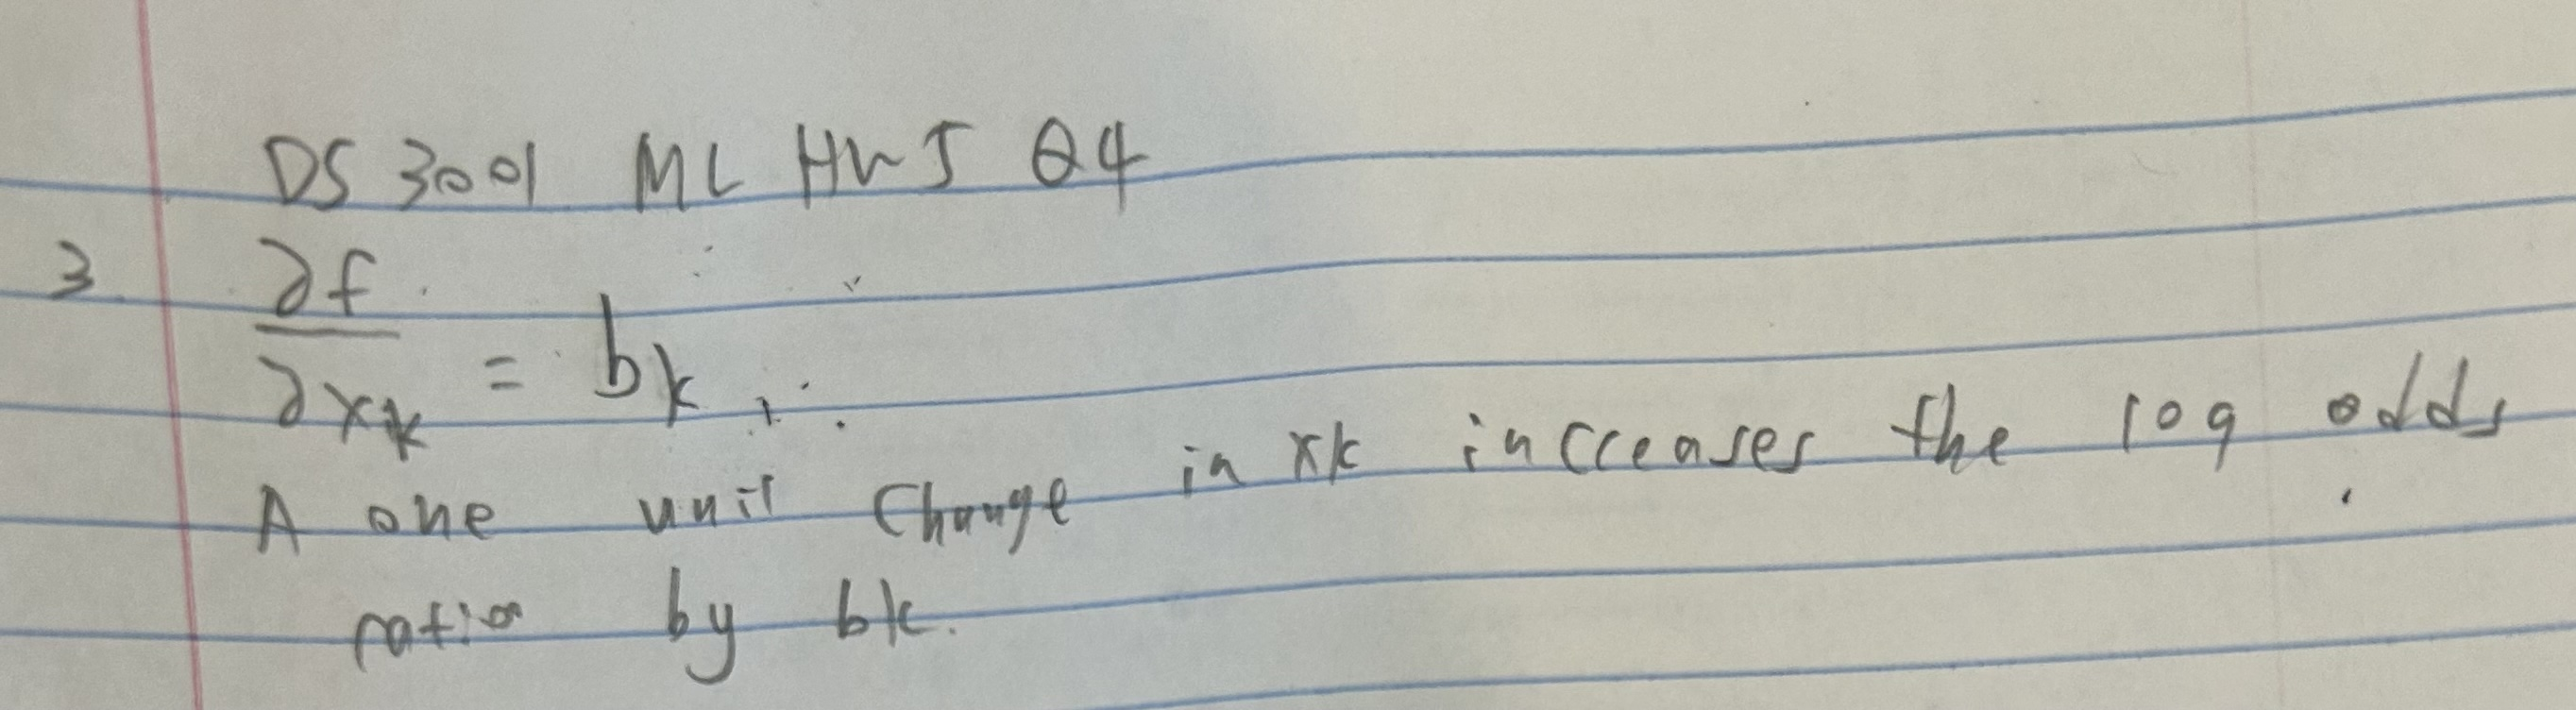